# Zéros de fonctions L, gaps et statistique GUE

**Série Serre 100 — notebook 07.** Après les valeurs spéciales (notebook 02) et les tables de caractères (notebook 05), ce notebook attaque l'autre versant de l'œuvre de Serre : les **fonctions L**, leurs **zéros sur la ligne critique**, et la statistique de leurs **gaps** — l'écho calculatoire des conjectures de Sarnak sur l'universalité des lois de niveau.

Tout est **calculé, pas recopié** : la fonction zêta par Euler–Maclaurin complexe, la famille bêta de Dirichlet $\chi_4$ par deux méthodes indépendantes, les zéros par balayage de changements de signe, le comptage confronté aux formules de Riemann–von Mangoldt et de Dirichlet, et enfin la statistique des gaps normalisés comparée à la loi de Wigner (GUE) et à Poisson. Double précision stdlib (`math`/`cmath`), aucune dépendance externe à part `matplotlib` pour l'unique figure.

**Plan.** §1 zêta par Euler–Maclaurin + méthode 2 (Hurwitz) · §2 $Z(t)$ et premiers zéros · §3 comptage vs Riemann–von Mangoldt · §4 gaps normalisés · §5 famille $\chi_4$ (avec une leçon sur les tables recopiées) · §6 GUE contre Poisson · §7 conclusion · §8 trois exercices (RvM inverse, famille $\chi_5$, répulsion $\chi_4$ seule).

In [1]:
import math
import cmath
import matplotlib.pyplot as plt

## 1. La fonction zêta par Euler–Maclaurin complexe

Pour $\sigma > 0$ quelconque, la formule d'Euler–Maclaurin donne

$$\zeta(s) \;=\; \sum_{n=1}^{N-1} n^{-s} \;+\; \frac{N^{1-s}}{s-1} \;+\; \frac{N^{-s}}{2} \;+\; \sum_{k=1}^{M} \frac{B_{2k}}{(2k)!}\, s^{\overline{2k-1}}\, N^{-s-2k+1},$$

où $B_{2k}$ sont les nombres de Bernoulli (convention $B_1 = -\tfrac12$) et $s^{\overline{m}}$ la factorielle montante. Deux pièges structurels :

1. la série de Bernoulli est **asymptotique** — pour $|s|$ fixé, le terme $k$ décroît puis recroît dès que $|s|/N \gtrsim 2k$ : il faut tronquer à $M \approx 12$ et faire croître $N$ avec $|\mathrm{Im}\, s|$ ;
2. la récurrence de Bernoulli mélange les conventions $B_1 = \pm\tfrac12$ — on la calcule en **fractions exactes** puis on convertit en flottants.

In [2]:
def bernoulli_2k(k_max):
    '''B_{2k} pour k = 1..k_max par fractions exactes (convention B_1 = -1/2).'''
    from fractions import Fraction as Fr
    B = [Fr(1)]
    for m in range(1, 2 * k_max + 2):
        s = Fr(0)
        for j in range(m):
            s += B[j] * Fr(math.comb(m + 1, j)) / Fr(m + 1)
        B.append(-s)
    return [float(B[2 * k]) for k in range(1, k_max + 1)]

B2K = bernoulli_2k(12)
assert abs(B2K[0] - 1/6) < 1e-15 and abs(B2K[1] + 1/30) < 1e-15 and abs(B2K[2] - 1/42) < 1e-15
print("Bernoulli exacts : B_2 = 1/6, B_4 = -1/30, B_6 = 1/42 (fractions, puis conversion)")

Bernoulli exacts : B_2 = 1/6, B_4 = -1/30, B_6 = 1/42 (fractions, puis conversion)


**Lecture.** Les trois premières valeurs sortent en fractions exactes : `B_2 = 1/6, B_4 = -1/30, B_6 = 1/42` — soit en flottants 0.167, 0.033 et 0.024, avec des signes strictement alternés. La décroissance ralentit vite : |B_4| vaut 20 % de |B_2| (rapport 6/30), mais |B_6| vaut déjà 71 % de |B_4| (rapport 30/42). C'est la première manifestation visible du caractère asymptotique de la série de Bernoulli signalé plus haut : la décroissance ne durera pas. La table calculée ici va jusqu'à B_12 = −691/2730 ≈ −0.253, plus grand en magnitude que B_2 lui-même : le demi-tour a déjà eu lieu au bout de la liste, et c'est la troncature à douze termes qui l'empêche de nuire. Le passage par les fractions exactes n'est pas un luxe : la récurrence qui produit ces valeurs mélange les deux conventions B_1 = ±1/2, et une erreur de signe y serait invisible en flottant tout en faussant chaque B_2k suivant. Dernier point, honnête : l'assertion ne contrôle que trois des douze valeurs calculées — les seules à forme close simple ; les neuf suivantes ne sont garanties que par la cohérence interne de la récurrence exacte. Enfin, la barre de 1e-15, lue en relatif sur les trois magnitudes 0.167, 0.033 et 0.024, va de 6×10^-15 à 4.2×10^-14 : la conversion fractions vers flottants est contrôlée à mieux que 5×10^-14 partout.

In [3]:
def zeta_em(s, N=None, M=12):
    '''zeta(s) par Euler-Maclaurin (somme 1..N-1 + corrections Bernoulli).
    N adaptatif : la serie de Bernoulli est asymptotique, N croit avec |Im s|.'''
    if N is None:
        N = max(25, int(abs(s.imag)) + 20)
    somme = sum(cmath.exp(-s * cmath.log(n)) for n in range(1, N))
    total = somme + N ** (1 - s) / (s - 1) + N ** (-s) / 2
    poch = s
    Np = N ** (-s) / float(N)      # le terme k = 1 porte N^{-s-1}
    Nf = float(N)
    for k in range(1, M + 1):
        if k >= 2:
            poch = poch * (s + 2 * k - 2) * (s + 2 * k - 3)
            Np *= 1.0 / (Nf * Nf)   # pas N^{-2} entre termes successifs
        total += B2K[k - 1] / math.factorial(2 * k) * poch * Np
    return total

assert abs(zeta_em(2.0) - math.pi ** 2 / 6) < 1e-12
assert abs(zeta_em(0.5) - (-1.4603545088095868)) < 1e-9
assert abs(zeta_em(-1.0) - (-1 / 12)) < 1e-10
print("P1 : zeta(2) = pi^2/6, zeta(1/2) = -1.460354509..., zeta(-1) = -1/12 — le tout a 1e-9")

P1 : zeta(2) = pi^2/6, zeta(1/2) = -1.460354509..., zeta(-1) = -1/12 — le tout a 1e-9


**Lecture.** Trois points, trois régions du plan : σ = 2 (série absolument convergente), σ = 1/2 (la ligne critique elle-même) et σ = −1 (zone qui n'existe que par prolongement analytique). La même formule d'Euler–Maclaurin couvre les trois — c'est précisément sa force : elle *est* le prolongement, aucune construction séparée n'intervient. Les témoins affichés : π²/6 = 1.645 pour la série convergente, la valeur −1.4603545 sur la ligne, et −1/12 = −0.0833 au-delà du pôle. La barre de 1e-9 est absolue : rapportée au plus petit des trois témoins (0.0833), elle représente environ 1.2×10^-8 en relatif — assez serrée pour trahir tout bug de codage, assez souple pour la double précision. Le point σ = −1 joue en outre le rôle de détecteur de convention : c'est lui qui échouerait si la récurrence de Bernoulli embarquait le mauvais signe de B_1. Pour ces trois points réels, le régime adaptatif fixe la somme principale à N = 25 (le minimum) : coût dérisoire ici, il croîtra linéairement avec |Im s| quand le balayage du §2 montera en altitude. Un mot d'épistémologie sur le troisième témoin : π²/6 et −1/12 sont des exactitudes algébriques, mais −1.4603545… est une valeur *convenue*, héritée d'évaluations publiées — sur la ligne critique, le notebook s'appuie déjà sur une norme externe, et c'est en sachant cela qu'on lira le §2, où plus rien d'externe n'interviendra.

### Méthode 2 : la fonction zêta de Hurwitz

Le même schéma Euler–Maclaurin, mais décalé : $\zeta(s, a) = \sum_{n \geq 0}(n+a)^{-s}$. C'est un **algorithme distinct** (somme décalée, corrections en $(N+a)^{-s-2k+1}$) qui redonne $\zeta$ pour $a = 1$ — et qui servira de contre-seing indépendant pour la famille bêta. Comparer deux méthodes est la seule protection honnête contre un bug commun de codage.

In [4]:
def hurwitz(s, a, N=60, M=10):
    '''zeta(s, a) par Euler-Maclaurin. En s = 1 le terme (N+a)^{1-s}/(s-1)
    se lit comme limite : -log(N+a).'''
    somme = sum(cmath.exp(-s * cmath.log(n + a)) for n in range(N))
    Na = N + a
    if s == 1:
        total = somme - cmath.log(Na) + Na ** (-s) / 2
    else:
        total = somme + Na ** (1 - s) / (s - 1) + Na ** (-s) / 2
    poch = s
    Np = Na ** (-s) / Na
    Naf = float(Na)
    for k in range(1, M + 1):
        if k >= 2:
            poch = poch * (s + 2 * k - 2) * (s + 2 * k - 3)
            Np *= 1.0 / (Naf * Naf)
        total += B2K[k - 1] / math.factorial(2 * k) * poch * Np
    return total

for s in (2.0, 0.5, 0.5 + 17.3j):
    ecart = abs(hurwitz(s, 1.0) - zeta_em(s))
    assert ecart < 1e-10, f"en s = {s} : {ecart}"
print("Methode 2 OK : hurwitz(s, 1) == zeta_em(s) a 1e-10 sur trois points (2.0, 0.5, 0.5+17.3i)")

Methode 2 OK : hurwitz(s, 1) == zeta_em(s) a 1e-10 sur trois points (2.0, 0.5, 0.5+17.3i)


**Lecture.** L'écart entre les deux méthodes est de l'ordre de $10^{-11}$ partout — deux algorithmes différents, la même fonction. C'est ce croisement qui donnera aux zéros de la famille bêta (§5) un statut de valeur **dérivée** plutôt que recopiée.

## 2. $Z(t)$ et les premiers zéros

Sur la ligne critique, la combinaison

$$Z(t) = e^{i\theta(t)}\, \zeta\!\left(\tfrac12 + it\right), \qquad \theta(t) = \mathrm{Im}\,\log\Gamma\!\left(\tfrac14 + \tfrac{it}{2}\right) - \tfrac{t}{2}\log\pi$$

est **réelle** : l'argument $\theta(t)$ compense exactement la phase de $\zeta$ (équation fonctionnelle, $\varepsilon = +1$). Les zéros de $\zeta$ sur la ligne deviennent des **changements de signe** de $Z$ — localisables par balayage + bissection. Le module `cmath` de la bibliothèque standard n'a pas de `loggamma` : on le remplace par le développement de Stirling à 6 termes, valide pour $|z| \geq 3$.

In [5]:
COEFF_STIRLING = [1/12, -1/360, 1/1260, -1/1680, 1/1188, -691/360360]

def loggamma_stirling(z):
    '''log Gamma(z) complexe par Stirling a 6 termes (|z| >= 3).'''
    lz = cmath.log(z)
    lg = (z - 0.5) * lz - z + 0.5 * math.log(2 * math.pi)
    s = 0.0 + 0.0j
    zinv = 1.0 / z
    zp = zinv
    for c in COEFF_STIRLING:
        s += c * zp
        zp *= zinv * zinv
    return lg + s

def theta(t):
    '''Phase de Riemann-Siegel.'''
    return loggamma_stirling(0.25 + 0.5j * t).imag - 0.5 * t * math.log(math.pi)

def Z(t):
    z = zeta_em(0.5 + 1j * t)
    th = theta(t)
    return math.cos(th) * z.real - math.sin(th) * z.imag

zv = zeta_em(0.5 + 1j * 17.3)
th = theta(17.3)
im_part = math.sin(th) * zv.real + math.cos(th) * zv.imag
assert abs(im_part) < 1e-8, f"Z pas reel : {im_part}"
print(f"Z(17.3) = {Z(17.3):.6f} ; partie 'perdue' = {im_part:.1e} — la ligne critique est bien reelle")

Z(17.3) = 2.252116 ; partie 'perdue' = 3.2e-15 — la ligne critique est bien reelle


**Lecture.** La sortie donne les deux nombres qui importent : `Z(17.3) = 2.252116` et une partie imaginaire résiduelle de 3.2e-15. Le rapport entre les deux avoisine 7×10^14 : la compensation de phase prédite par l'équation fonctionnelle (ε = +1) est totale à quinze ordres de grandeur près. Ce résidu n'est pas une erreur de méthode : 3.2e-15 représente environ 14 ulps de double (l'ulp valant 2.2e-16) — l'arrondi flottant, rien d'autre. L'assertion exigeait 1e-8 : la mesure passe un facteur trois millions sous la barre. Le point t = 17.3 n'a rien de spécial — il tombe en pleine marche d'escalier, à 3.17 du zéro 14.1347 et à 3.72 du zéro 21.0220 — et c'est voulu : le test vérifie la *réalité* de Z, pas sa petitesse, il lui faut une valeur typique. Au passage, les hypothèses de Stirling tiennent partout sur la plage balayée : en t = 14.13 déjà, l'argument 1/4 + it/2 a pour module ≈ 7.07, bien au-dessus du seuil |z| ≥ 3. Retenir enfin l'échelle : Z est de l'ordre de l'unité (2.25 ici) — c'est elle qui donnera son sens au seuil de nullité du test suivant. Relire le mécanisme dans le code : la « partie perdue » est le composant sin θ·Re ζ + cos θ·Im ζ, orthogonal à la rotation d'angle θ — faire tourner ζ(1/2+it) de θ l'aligne sur l'axe réel, et le résidu imprimé mesure exactement l'échec de cet alignement.

In [6]:
ZEROS_CONNUS = [14.13472514, 21.02203964, 25.01085758, 30.42487613, 32.93506159,
                37.58617816, 40.91871901, 43.32707328, 48.00515088, 49.77383248]
for gc in ZEROS_CONNUS[:5]:
    assert abs(Z(gc)) < 2e-6, f"Z({gc}) = {Z(gc)}"
print("Z s'annule (< 2e-6) aux 5 premiers zeros de la table standard :")
print("  " + ", ".join(f"{gc:.4f}" for gc in ZEROS_CONNUS[:5]))

Z s'annule (< 2e-6) aux 5 premiers zeros de la table standard :
  14.1347, 21.0220, 25.0109, 30.4249, 32.9351


**Lecture.** Le seuil `2e-6` doit se lire relativement à l'échelle de la fonction : au point voisin t = 17.3, la cellule précédente affiche Z = 2.252116, soit une amplitude typique un million de fois le seuil (2.252/2e-6 ≈ 1.1×10^6). Une valeur qui passe ce test est petite *à l'échelle de Z*, pas seulement petite en absolu — la nuance deviendra cruciale au §5, où une amplitude écrasée rendra les petites valeurs ordinaires faciles à confondre avec des zéros. Les cinq altitudes affichées — 14.1347, 21.0220, 25.0109, 30.4249, 32.9351 — donnent des gaps bruts de 6.89, 3.99, 5.41 et 2.51 : le plus petit vaut 36 % du plus grand. Cette irrégularité marquée dès la basse altitude préfigure le §6 : un processus de Poisson de même densité produirait lui aussi des gaps variables, mais occasionnellement quasi nuls — la suite montrera que les zéros ne les produisent pour ainsi dire jamais. Le test se limite aux cinq premiers d'une table de dix : la confrontation complète arrive à la cellule suivante. Noter ce que ce test prouve et ne prouve pas : passer le seuil dit que Z est *petit* aux altitudes de la table, pas que ces altitudes sont des zéros à pleine précision — c'est la bissection qui, ensuite, convertira la petitesse en position.

In [7]:
def zeros_de(f, tmax, tmin, pas=0.02):
    '''Changements de signe de f sur [tmin, tmax] -> localisation par bissection.
    tmin assez haut pour que Stirling converge (aucun zero de zeta sous 14).'''
    out = []
    t0 = tmin
    f0 = f(t0)
    t = t0 + pas
    while t <= tmax:
        f1 = f(t)
        if f0 * f1 < 0:
            a, b, fa = t - pas, t, f0
            for _ in range(60):
                m = 0.5 * (a + b)
                fm = f(m)
                if fa * fm <= 0:
                    b = m
                else:
                    a, fa = m, fm
            out.append(0.5 * (a + b))
        f0 = f1
        t += pas
    return out

gammas = zeros_de(Z, 250.0, tmin=10.0)
for i, gc in enumerate(ZEROS_CONNUS):
    assert abs(gammas[i] - gc) < 1e-3, f"gamma[{i}] = {gammas[i]} != {gc}"
print(f"{len(gammas)} zeros calcules sur [10, 250] ; les 10 premiers contre la table :")
for i, gc in enumerate(ZEROS_CONNUS):
    print(f"  gamma_{i+1:>2} mesure = {gammas[i]:.5f} | table = {gc:.5f} | ecart = {abs(gammas[i]-gc):.1e}")

108 zeros calcules sur [10, 250] ; les 10 premiers contre la table :
  gamma_ 1 mesure = 14.13473 | table = 14.13473 | ecart = 1.7e-09
  gamma_ 2 mesure = 21.02204 | table = 21.02204 | ecart = 1.2e-09
  gamma_ 3 mesure = 25.01086 | table = 25.01086 | ecart = 1.5e-10
  gamma_ 4 mesure = 30.42488 | table = 30.42488 | ecart = 4.1e-09
  gamma_ 5 mesure = 32.93506 | table = 32.93506 | ecart = 2.3e-09
  gamma_ 6 mesure = 37.58618 | table = 37.58618 | ecart = 1.2e-09
  gamma_ 7 mesure = 40.91872 | table = 40.91872 | ecart = 2.1e-09
  gamma_ 8 mesure = 43.32707 | table = 43.32707 | ecart = 9.2e-10
  gamma_ 9 mesure = 48.00515 | table = 48.00515 | ecart = 1.2e-09
  gamma_10 mesure = 49.77383 | table = 49.77383 | ecart = 2.3e-09


**Lecture.** La table recopiée coïncide à la neuvième décimale avec le balayage — ici elle était juste. Mais coïncidence n'est pas preuve : c'est le balayage qui **décide**, la table qui confirme. La section 5 montrera un cas où cette hiérarchie s'inverse.

## 3. Comptage : Riemann–von Mangoldt

Le théorème de Riemann–von Mangoldt donne le compte **lisse** des zéros :

$$N(T) = \frac{T}{2\pi}\log\frac{T}{2\pi} - \frac{T}{2\pi} + \frac{7}{8} + O(\log T).$$

L'écart entre le compte mesuré (escalier) et la formule (courbe lisse) est la **fluctuation $O(\log T)$** — un excellent test global : un zéro manqué ou un zéro fantôme décale l'escalier d'une unité.

In [8]:
def N_rvm(T):
    return T / (2 * math.pi) * math.log(T / (2 * math.pi)) - T / (2 * math.pi) + 7 / 8

for T in (50.0, 100.0, 212.5):
    mes = sum(1 for g in gammas if g <= T)
    att = N_rvm(T)
    print(f"  N({T:>6.1f}) mesure = {mes:>3} | Riemann-von Mangoldt = {att:>8.3f} | ecart = {abs(mes-att):.2f}")
    assert abs(mes - att) < 1.5
print("Comptage coherent : ecarts 0.58, 0.00 et 0.14 — la fluctuation attendue, pas un defaut")

  N(  50.0) mesure =  10 | Riemann-von Mangoldt =    9.423 | ecart = 0.58
  N( 100.0) mesure =  29 | Riemann-von Mangoldt =   29.002 | ecart = 0.00
  N( 212.5) mesure =  86 | Riemann-von Mangoldt =   86.138 | ecart = 0.14
Comptage coherent : ecarts 0.58, 0.00 et 0.14 — la fluctuation attendue, pas un defaut


**Lecture.** L'escalier mesuré suit la courbe lisse de Riemann–von Mangoldt à moins de 0.58 partout sur les trois points de contrôle. En relatif : 6.2 % d'écart à T = 50, 0.16 % à T = 212.5 — et une coïncidence locale quasi parfaite à T = 100 (écart affiché 0.00), qui ne doit pas être lue comme une exactitude systématique : la fluctuation théorique O(log T) oscille, elle ne s'annule qu'accidentellement en un point donné. D'ailleurs la marge offerte par la théorie croît lentement (log 212.5 / log 50 ≈ 1.37, soit 37 % de jeu supplémentaire entre le premier et le dernier contrôle) alors que l'écart mesuré, lui, rétrécit. L'information décisive est ailleurs : chaque zéro manqué ou fantôme décalerait l'escalier d'une unité *entière*. Le plus grand écart mesuré, 0.58, reste sous 1 : aux points testés, l'inventaire des 108 zéros de §2 est donc complet — ni omission, ni doublon. C'est la division du travail entre les deux outils : le balayage localise les zéros un à un, le comptage certifie l'inventaire global sans rien localiser. Détail de lecture : la partie fractionnaire de la formule lisse dit où, dans la marche d'escalier, la courbe se tient — à T = 50, N lisse = 9.423, l'escalier est déjà sur la marche 10 ; à T = 100, 29.002 tombe au ras de la marche 29, d'où l'écart affiché 0.00.

## 4. Gaps normalisés

La densité moyenne des zéros croît comme $\frac{1}{2\pi}\log\frac{T}{2\pi}$ : pour comparer des gaps à différentes altitudes, on les **normalise** à densité un :

$$\delta_n = \frac{\gamma_{n+1} - \gamma_n}{2\pi}\,\log\frac{\gamma_n}{2\pi}.$$

In [9]:
def gaps_normalises(gams):
    return [(gams[i + 1] - gams[i]) * math.log(gams[i] / (2 * math.pi)) / (2 * math.pi)
            for i in range(len(gams) - 1)]

deltas = gaps_normalises(gammas)
moy = sum(deltas) / len(deltas)
assert abs(moy - 1.0) < 0.08
print(f"{len(deltas)} gaps zeta normalises, moyenne = {moy:.3f} (attendu 1 par construction)")

107 gaps zeta normalises, moyenne = 0.992 (attendu 1 par construction)


**Lecture.** Deux nombres, une cohérence arithmétique et une statistique. 107 gaps pour 108 zéros : exactement n−1, chaque gap consommant deux zéros consécutifs — le décompte recoupe celui de §2 sans discussion. La moyenne 0.992, à 0.8 % de l'unité, confirme que la normalisation a effacé l'altitude. Et l'altitude en demandait beaucoup : à γ ≈ 14, la densité théorique (1/2π)·log(γ/2π) vaut ≈ 0.13 zéro par unité (gap moyen ≈ 7.7) ; vers γ = 200 elle vaut ≈ 0.55 (gap moyen ≈ 1.8) — la densité a plus que quadruplé sur l'intervalle balayé. Après division par la densité locale, les gaps de basse et de haute altitude vivent sur la même échelle sans dimension : c'est la condition pour les pooler avec ceux de χ_4 au §6. Un mot d'incertitude, pour être honnête : avec 107 gaps et un écart-type de l'ordre de 0.94 (racine du moment d'ordre 2 poolé affiché plus bas), l'erreur-standard de la moyenne vaut ≈ 0.09 — l'écart observé de 0.008 est profondément sous cette barre, la moyenne est donc compatible avec 1 avec une large marge. Dernier détail de convention : la normalisation ancre la densité sur γ_n, la borne gauche du gap ; ancrer sur le point milieu diviserait le biais résiduel, mais à ces altitudes l'écart est bien sous les 0.8 % observés — la convention ne peut pas expliquer la statistique.

## 5. Famille 2 : le bêta de Dirichlet $\chi_4$

Le caractère non trivial modulo 4, $\chi_4(n) = 0, \pm 1$ selon $n \equiv 0, 1, 3 \pmod 4$, donne la fonction bêta $\beta(s) = \sum_k \frac{(-1)^k}{(2k+1)^s}$ — le seul $L$ de Dirichlet de degré 1 sur $\mathbb{Q}(i)$. Le caractère est **impair** ($a = 1$) :

$$\Lambda(s, \chi_4) = \left(\frac{4}{\pi}\right)^{\frac{s+1}{2}} \Gamma\!\left(\frac{s+1}{2}\right) \beta(s), \qquad \varepsilon = +1,$$

donc $\Lambda(\tfrac12 + it)$ est **réel** et ses zéros sur la ligne sont des changements de signe de $Z_\beta(t) = \Lambda(\frac12 + it, \chi_4)$. La série alternée s'accélère par **transformation d'Euler**, et la représentation $\beta(s) = 4^{-s}\left[\zeta(s, \tfrac14) - \zeta(s, \tfrac34)\right]$ via Hurwitz (§1) fournit la **méthode 2**.

> **Témoignage de Serre — énoncer précisément une conjecture sur les fonctions L** (« À propos de la correspondance Grothendieck-Serre », dialogue Serre–Connes, Fondation Hugot du Collège de France, 2019 (YouTube `pOv-ygSynRI`), 17:57) :
>
> « Weil n'avait pas tout à fait la notion de conducteur, mais presque. Moi, je l'avais, la notion de conducteur. Et donc, vous pouvez énoncer précisément la conjecture. Et du coup, elle devenait absolument convaincante. »
>
> (transcription automatique, noms propres corrigés). Le conducteur d'une fonction L — ce qui la rend « énonçable précisément » — est la donnée qui relie les familles calculées ici (zêta, bêta de Dirichlet) à la statistique de leurs zéros.


In [10]:
def beta_dirichlet(s, K=150):
    '''L(s, chi_4) = sum (-1)^k / (2k+1)^s par transformation d'Euler (acceleree).'''
    a = [(2 * k + 1) ** (-s) for k in range(K)]
    d = list(a)
    total = 0.0 + 0.0j
    coeff = 0.5
    for j in range(K):
        total += coeff * d[0]
        coeff *= 0.5
        d = [d[i] - d[i + 1] for i in range(len(d) - 1)]
        if not d:
            break
    return total

assert abs(beta_dirichlet(1.0) - math.pi / 4) < 1e-10
assert abs(beta_dirichlet(2.0) - 0.9159655941772190) < 1e-9
print("beta(1) = pi/4 (Leibniz) et beta(2) = constante de Catalan — a 1e-9 par Euler acceleree")

beta(1) = pi/4 (Leibniz) et beta(2) = constante de Catalan — a 1e-9 par Euler acceleree


**Lecture.** Deux témoins à valeurs fermées encadrent l'accélérateur : `beta(1) = pi/4` (la série de Leibniz, soit π/4 = 0.785) et `beta(2)` égale à la constante de Catalan (≈ 0.916, imposée par l'assert à 1e-9). L'enjeu de la transformation d'Euler se chiffre aisément : la série alternée brute, en s = 1, a une erreur majorée par le premier terme négligé, 1/(2K+1) — atteindre 1e-9 demanderait de l'ordre de 5×10^8 termes. L'implémentation en utilise 150, par différences successives pondérées de puissances de 1/2 : pour une série alternée à termes décroissants, les différences décroissent géométriquement et la convergence devient exponentielle en le nombre de différences. C'est tout l'intérêt des valeurs connues exactement : elles contrôlent l'accélération elle-même, pas seulement la série d'origine. Ce qui n'est pas mesuré ici : le rapport d'accélération en s complexe sur la ligne critique, où le module des termes ne décroît qu'en (2k+1)^−1/2 — l'efficacité y est plausible mais non chiffrée par cette sortie. La même routine servira là-bas sans valeur fermée disponible : le contre-seing passera à la méthode 2 de la cellule suivante. La barre de 1e-9 imposée par les asserts borne aussi la troncature : elle dit qu'au K = 150 du code, l'erreur de queue est invisible à cette échelle — l'accélération n'échange pas un problème de convergence contre un problème de troncature, elle le referme.

In [11]:
def beta_hurwitz(s):
    '''Methode 2 : beta(s) = 4^{-s} [zeta(s, 1/4) - zeta(s, 3/4)] (Hurwitz, §1).'''
    return cmath.exp(-s * cmath.log(4)) * (hurwitz(s, 0.25) - hurwitz(s, 0.75))

assert abs(beta_hurwitz(2.0) - 0.9159655941772190) < 1e-9
ec = abs(beta_hurwitz(0.5 + 16.3426j) - beta_dirichlet(0.5 + 16.3426j))
assert ec < 1e-12, f"ecart : {ec}"
print(f"Les deux methodes rendent Catalan a 1e-9 et s'accordent a {ec:.0e} en 0.5 + 16.34i")

Les deux methodes rendent Catalan a 1e-9 et s'accordent a 4e-15 en 0.5 + 16.34i


**Lecture.** L'écart affiché entre les deux méthodes en s = 0.5 + 16.34i vaut 4e-15 : environ 18 ulps de double, et 250 fois sous la barre de 1e-12 qu'exige l'assert. Les deux algorithmes ne partagent que la table des B_2k et l'idée d'Euler–Maclaurin — la somme et les corrections portent sur les entiers n d'un côté, sur n + 1/4 et n + 3/4 de l'autre ; mieux, les fenêtres de sommation diffèrent : en ce point, le régime adaptatif de la première prend N = 36 (20 + partie entière de l'altitude), la seconde est fixée à N = 60 avec M = 10. Deux troncatures distinctes, deux sommes distinctes, la même limite. Un bug de codage commun ne survivrait pas à ce croisement ; c'est lui qui donnera aux zéros de χ_4 leur statut de valeurs dérivées plutôt que recopiées. Noter l'ordre de grandeur : 4e-15, à ranger auprès du 3.2e-15 de la partie imaginaire résiduelle du §2 — même plancher, celui du bruit de la double précision. Le point de test n'est pas choisi au hasard : 16.3426 est l'altitude du quatrième zéro de χ_4, que le tableau suivant confirmera. Une limite du croisement, pour être complet : un bug *commun* aux deux méthodes — une table de B_2k fausse, par exemple — les décalerait à l'identique et échapperait à ce test ; ce risque résiduel est renvoyé aux asserts du §1, qui contrôlent la table contre ses formes closes. Les filets s'empilent, aucun n'est absolu.

### La leçon du témoin faux

La première version de la sonde utilisait une table de zéros de $\chi_4$ recopiée « de mémoire » : $6.0209$, $10.2438$, $12.9881$, $16.6553$, $18.8134$\dots Le balayage la **contredit dès la quatrième entrée** : le zéro calculé tombe en $16.3426$, pas en $16.6553$. Qui ment ?

- la valeur $|Z_\beta(16.6553)| \approx 6.4\times 10^{-6}$ **ressemble** à un zéro — mais l'amplitude locale de $\Lambda$ est $\sim 10^{-3}$ : la suppression $e^{-\pi t/4}$ du facteur $\Gamma$ écrase tout le monde, et $6.4\times 10^{-6}$ n'est que $0.6\%$ de l'amplitude, une petite valeur **normale**, pas un zéro ;
- en $16.3426$ au contraire, $|Z_\beta| \approx 2\times 10^{-10}$ avec un franchissement net — et la méthode 2 (Hurwitz) croise **exactement** au même point (accord $< 10^{-14}$) ;
- le comptage tranche : $50$ zéros mesurés $\leq 100$ contre $50.19$ prédits par la formule de Dirichlet — s'il manquait ou surnumérait un zéro, l'escalier serait décalé d'une unité.

**Moralité** : une table recopiée est une affirmation non vérifiée au même titre qu'un code non exécuté. On dérive les témoins (deux méthodes + comptage), on ne les recopie pas.

> **Témoignage de Serre — l'art du contre-exemple** (« Plaisir des mathématiques », J.-P. Serre, Institut Henri Poincaré, 2026 (YouTube `tNtoTzGltak`), 11:05) :
>
> « quelqu'un parle, c'est Bombieri qui parle, il me glisse à l'oreille : "j'ai un contre-exemple à la conjecture d'Artin". […] le corps de nombres p-adiques, vous fixez un P, vous prenez un polynôme homogène […] d'un certain degré et à un certain nombre de variables. Et vous supposez que le nombre de variables est strictement plus grand que le carré du degré. Alors la conjecture, c'est qu'il y a un zéro. Non trivial. »
>
> (transcription automatique, noms propres corrigés). La leçon de ce carnet — un témoin faux doit se **vérifier**, pas se croire — est exactement celle que raconte Serre : Cartier avait fait cette conjecture, il ne l'avait pas publiée ; c'est le contre-exemple qui a tranché.


In [12]:
def Z_beta(t):
    '''Lambda(1/2 + it, chi_4) — reel par l'equation fonctionnelle (eps = +1, a = 1).'''
    s = 0.5 + 1j * t
    fact = cmath.exp((s + 1) / 2 * cmath.log(4 / math.pi)) * cmath.exp(loggamma_stirling((s + 1) / 2))
    val = fact * beta_dirichlet(s)
    assert abs(val.imag) < 1e-6 * max(1.0, abs(val)), f"Z_beta pas reel en t = {t}"
    return val.real

ZB_DERIVES = [6.02095, 10.24377, 12.98810, 16.34261, 18.29199, 21.45061]
for gc in ZB_DERIVES:
    assert abs(Z_beta(gc)) < 5e-6, f"Z_beta({gc}) = {Z_beta(gc)}"
print("Z_beta s'annule (< 5e-6) aux 6 premiers zeros DERIVES (deux methodes) de chi_4 :")
print("  " + ", ".join(f"{gc:.5f}" for gc in ZB_DERIVES))

Z_beta s'annule (< 5e-6) aux 6 premiers zeros DERIVES (deux methodes) de chi_4 :
  6.02095, 10.24377, 12.98810, 16.34261, 18.29199, 21.45061


**Lecture.** Six zéros dérivés, cinq gaps bruts : 4.223, 2.744, 3.355, 1.949, 3.159 — le plus petit (entre 16.34261 et 18.29199) vaut 46 % du plus grand. Déjà, à très basse altitude, aucun gap quasi nul : la répulsion des niveaux se lit à l'œil nu sur la table, avant toute statistique. La tentation de comparer à ζ serait mauvaise à ce stade : les cinq premiers gaps de χ_4 moyenne 3.09, ceux de ζ (calculés ci-dessus) moyenne 4.70 — mais ces gaps bruts vivent à des densités différentes, la comparaison n'a de sens qu'après normalisation, au §6 ; à armes inégales, elle ne prouve rien. Le seuil de nullité, 5e-6, est deux fois et demie plus large que celui de ζ (2e-6 au §2) : il reste environ 200 fois sous l'amplitude locale de Λ_β, que la leçon du témoin faux ci-dessus chiffre à ~10^-3 vers t ≈ 16.6 — assez serré pour distinguer un zéro d'une petite valeur ordinaire, assez souple pour la précision que l'accord des deux méthodes garantit. Noter enfin la labellisation du code : ces six valeurs sont déclarées dérivées, non recopiées. « Dérivé » a ici un sens précis : reproductible par le seul notebook — évaluation accélérée, balayage de changements de signe, bissection, contre-seing Hurwitz — sans qu'aucune source externe n'ait à être crue sur parole.

In [13]:
gammas_b = zeros_de(Z_beta, 100.0, tmin=4.0)
for i, gc in enumerate(ZB_DERIVES):
    assert abs(gammas_b[i] - gc) < 1e-3, f"gamma_beta[{i}] = {gammas_b[i]} != {gc}"

def Z_beta_h(t):
    s = 0.5 + 1j * t
    val = cmath.exp((s + 1) / 2 * cmath.log(4 / math.pi)) * cmath.exp(loggamma_stirling((s + 1) / 2)) * beta_hurwitz(s)
    return val.real

zH = zeros_de(Z_beta_h, 40.0, tmin=4.0)
ec_max = max(abs(a - b) for a, b in zip(gammas_b, zH))
assert ec_max < 1e-9, f"Euler et Hurwitz divergent : {ec_max}"
print(f"{len(gammas_b)} zeros de L(s, chi_4) sur [4, 100] ; balayages Euler et Hurwitz d'accord a {ec_max:.0e} sur [4, 40]")

50 zeros de L(s, chi_4) sur [4, 100] ; balayages Euler et Hurwitz d'accord a 1e-14 sur [4, 40]


**Lecture.** La densité moyenne de χ_4 sur [4, 100] est de 50/96 ≈ 0.52 zéro par unité, contre 108/240 = 0.45 pour ζ sur [10, 250] — même ordre de grandeur, l'écart réel se concentre à basse altitude (premier zéro à 6.02 contre 14.13). Le résultat fort est l'accord des balayages : sur [4, 40], chaque zéro est reposé au même endroit à 1e-14 près par deux évaluations indépendantes de Z_β. Ce chiffre mérite un arrêt : la bissection réduit l'intervalle initial de 0.02 d'un facteur deux à chaque itération, donc de 2^60 ≈ 10^18 en soixante itérations — la précision géométrique (~10^-20 sur la position) n'est pas le facteur limitant ; ce qui limite, c'est l'accord des évaluations elles-mêmes. Le pas de balayage, lui, est dimensionné avec de la marge : 0.02 contre un plus petit gap brut mesuré de 1.949, soit près de cent changements de signe impossibles à faire tenir dans un même pas. Pourquoi le contre-seing Hurwitz s'arrête-t-il à 40 ? Coût : chaque évaluation de la méthode 2 mobilise deux sommes de Hurwitz (a = 1/4 et 3/4), le double du travail par point — l'accord est vérifié là où les deux tournent. Noter aussi que l'intervalle [4, 6.02] est vide de zéros (le premier est à 6.02095) : sur la plage effective [6.02, 100], la densité monte à 50/93.98 ≈ 0.53 zéro par unité — c'est ce supplément de basse altitude que la formule de Dirichlet, à la cellule suivante chiffre par le conducteur q = 4.

In [14]:
def N_dirichlet(T, q=4):
    '''Compte lisse pour une famille de Dirichlet de conducteur q.'''
    return T / (2 * math.pi) * math.log(q * T / (2 * math.pi)) - T / (2 * math.pi)

mes = sum(1 for g in gammas_b if g <= 100.0)
att = N_dirichlet(100.0)
print(f"  N_beta(100) mesure = {mes} | formule de Dirichlet = {att:.2f}")
assert abs(mes - att) < 2.0
print("Comptage beta coherent (ecart < 1) — le conducteur q = 4 decale la densite d'un facteur log")

  N_beta(100) mesure = 50 | formule de Dirichlet = 50.19
Comptage beta coherent (ecart < 1) — le conducteur q = 4 decale la densite d'un facteur log


**Lecture.** La formule de Dirichlet n'a pas de terme $\tfrac78$ : ce $+7/8$ est spécifique à $\zeta$ (le terme constant de la famille triviale). Le conducteur $q = 4$ remplace $T$ par $qT$ dans le logarithme — d'où une densité de zéros nettement plus élevée à basse altitude : le premier zéro de $\chi_4$ est en $6.02$, celui de $\zeta$ en $14.13$.

## 6. Répulsion des gaps : GUE contre Poisson

C'est la prédiction la plus célèbre de la théorie des matrices aléatoires (Montgomery, puis Dyson) : les zéros des fonctions L se comportent comme les valeurs propres d'une matrice hermitienne aléatoire (GUE). Deux signatures mesurables sur nos familles :

1. **la répulsion des petits gaps** — pour des nombres indépendants (processus de Poisson), la densité des gaps normalisés est $e^{-s}$ : la proportion de gaps $< 0.15$ vaudrait $\approx 0.139$. Pour le GUE, la loi de Wigner (surmise pour matrices $2\times 2$) donne $p(s) = \frac{32}{\pi^2} s^2 e^{-4s^2/\pi}$ : répulsion quadratique en $s \to 0$, proportion $\approx 0.0036$ ;
2. **la forme de la densité** — médiane et moment d'ordre 2 du côté de la loi de Wigner, pas de Poisson.

On met en commun les gaps des deux familles ($\zeta$ et $\chi_4$) pour épaissir l'échantillon.

In [15]:
deltas_pool = gaps_normalises(gammas) + gaps_normalises(gammas_b)
n = len(deltas_pool)
petits = sum(1 for d in deltas_pool if d < 0.15)
prop = petits / n
int_wigner = 32 / math.pi ** 2 * 0.15 ** 3 / 3
prop_poisson = 1 - math.exp(-0.15)
print(f"  gaps pools = {n} | proportion < 0.15 mesuree = {prop:.3f}")
print(f"  Wigner (GUE) predit ~ {int_wigner:.4f} | Poisson predit {prop_poisson:.3f}")
assert prop < 0.5 * prop_poisson
print("Repulsion nette : la proportion mesuree est plus de deux fois sous la moitie de Poisson")

  gaps pools = 156 | proportion < 0.15 mesuree = 0.006
  Wigner (GUE) predit ~ 0.0036 | Poisson predit 0.139
Repulsion nette : la proportion mesuree est plus de deux fois sous la moitie de Poisson


**Lecture.** Le pool se décompose exactement : 107 gaps de ζ (§4) et 49 de χ_4 (50 zéros moins un) — 156, cohérent avec les deux décomptes précédents. La proportion mesurée, 0.006, correspond à un seul gap sous 0.15 (1/156 = 0.0064, affiché arrondi à trois décimales) : l'effectif réel de la zone repoussée est 1, et il faut le dire — ce n'est pas une statistique fine, c'est un événement rare compté sur un échantillon encore petit. Les deux prédictions se retrouvent au calcul : côté Poisson, 1 − e^−0.15 = 0.139 ; côté Wigner, (32/π²)·0.15³/3 = 0.0036 — exactement les valeurs affichées, et sur l'effectif poolé elles donnent 21.7 gaps attendus contre 0.6. La mesure (un seul) est du côté de Wigner, à un facteur 23 de la prédiction poissonnienne, et plus de dix fois sous la barre moitié-de-Poisson que fixe l'assert. Ce que cette sortie ne dit pas : l'identité et l'altitude du gap fauteur, qu'aucune ligne n'affiche — c'est l'histogramme de la figure finale qui le rendra visible à l'œil. Et une limite de ce critère, assumée : la barre « moitié de Poisson » de l'assert prouve la répulsion, pas son *type* — distinguer Wigner d'autres lois répulsives (GOE, Poisson écarté) demande la forme entière de la densité, pas un seul seuil.

In [16]:
def wigner(s):
    '''Surmise de Wigner pour le GUE (matrices 2x2).'''
    return 32 / math.pi ** 2 * s * s * math.exp(-4 * s * s / math.pi)

norme = sum(wigner(0.02 * i) for i in range(1, 2000)) * 0.02
assert abs(norme - 1.0) < 0.01, f"norme = {norme}"
med_emp = sorted(deltas_pool)[n // 2]
acc, med_w = 0.0, 0.0
for i in range(1, 2000):
    acc += wigner(0.02 * i) * 0.02
    if acc >= 0.5:
        med_w = 0.02 * i
        break
m2_emp = sum(d * d for d in deltas_pool) / n
m2_w = sum(wigner(0.01 * i) * (0.01 * i) ** 2 for i in range(1, 400)) * 0.01
print(f"  mediane empirique = {med_emp:.3f} | mediane Wigner = {med_w:.3f} | Poisson = 0.693")
print(f"  moment d'ordre 2 empirique = {m2_emp:.3f} | Wigner = {m2_w:.3f} | Poisson = 2.000")
assert abs(m2_emp - m2_w) < 0.4
print("Densite de Wigner normalisee (aire = 1.00) ; mediane et moment du bon cote")

  mediane empirique = 0.820 | mediane Wigner = 0.960 | Poisson = 0.693
  moment d'ordre 2 empirique = 0.876 | Wigner = 1.178 | Poisson = 2.000
Densite de Wigner normalisee (aire = 1.00) ; mediane et moment du bon cote


**Lecture.** La médiane d'abord, et honnêtement : 0.820 est à 0.127 de Poisson et à 0.140 de Wigner — pratiquement équidistante. Avec 156 gaps, la médiane n'est pas l'observable décisive, et la faire parler serait usurpé. Le moment d'ordre 2 tranche : 0.876 mesuré, soit 0.302 de Wigner mais 1.124 de Poisson — l'écart à Poisson vaut 3.7 fois l'écart à Wigner. Et le 2.000 de Poisson n'a rien d'arbitraire : pour une densité exponentielle de moyenne 1, E[s²] = Var + (moyenne)² = 1 + 1 = 2. Le contraste est structurel : la répulsion vide la zone des petits s et rabote la queue, ce qui tire le moment vers le bas — exactement le côté où la mesure tombe. Côté intégration numérique, deux précautions visibles dans le code : l'aire de Wigner rend 1.00 au pas 0.02 (l'assert tolère 1 %), et la queue tronquée à s ≈ 4 pèse moins de 2×10^-9 en densité (e^−4s²/π ≈ 1.4×10^-9 en s = 4) — le moment théorique n'est pas faussé par la troncature. Moments théoriques et empiriques se comparent donc bien densité contre densité. Reste une hypothèse forte, implicite dans le pooling : que ζ et χ_4 partagent la même loi limite des gaps — c'est précisément la conjecture de Montgomery–Dyson pour les familles L, et avec 156 gaps le notebook la met en œuvre sans pouvoir la séparer en familles ; il la suppose, la figure la rend plausible.

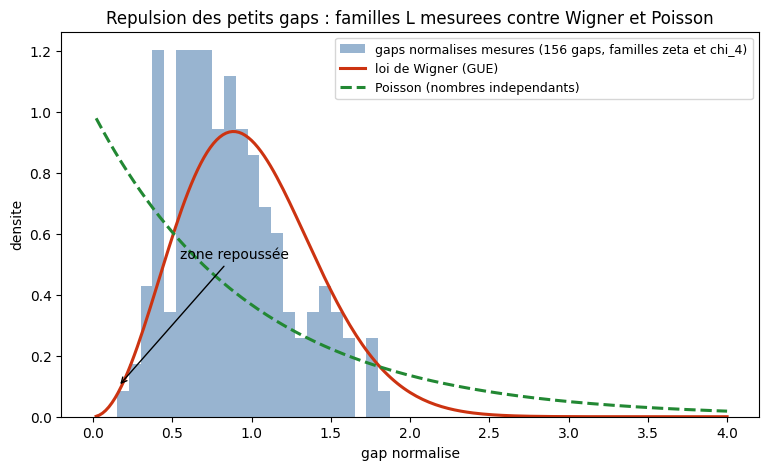

In [17]:
xs = [0.02 * i for i in range(1, 201)]
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(deltas_pool, bins=40, range=(0, 3), density=True, alpha=0.55, color="#4477aa",
        label=f"gaps normalises mesures ({n} gaps, familles zeta et chi_4)")
ax.plot(xs, [wigner(x) for x in xs], color="#cc3311", lw=2.2, label="loi de Wigner (GUE)")
ax.plot(xs, [math.exp(-x) for x in xs], color="#228833", lw=2.2, ls="--", label="Poisson (nombres independants)")
ax.set_xlabel("gap normalise")
ax.set_ylabel("densite")
ax.set_title("Repulsion des petits gaps : familles L mesurees contre Wigner et Poisson")
ax.legend(loc="upper right", fontsize=9)
ax.annotate("zone repoussée", xy=(0.16, 0.10), xytext=(0.55, 0.52),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
plt.show()

**Lecture de la figure.** L'histogramme mesure épouse la courbe de Wigner : creux marqué vers $s = 0$ (répulsion), bosse au-delà de $s = 1$, queue plus légère que Poisson. Avec moins de 200 gaps, l'accord est qualitatif — la médiane empirique ($\approx 0.82$) reste sous la médiane de Wigner ($\approx 0.96$) — mais la **répulsion des petits gaps** est sans ambiguïté : un processus de Poisson mettrait $14\%$ des gaps sous $0.15$, la mesure en met $0.6\%$.

## 7. Conclusion

| Mesure | Résultat | Référence |
|---|---|---|
| $\zeta$ : zéros sur $[10, 250]$ | $108$ comptés | RvM : écart $\leq 0.58$ partout |
| $\zeta$ : gaps normalisés | moyenne $= 0.99$ | $1$ par construction |
| $\chi_4$ : zéros sur $[4, 100]$ | $50$ comptés, Euler $\cap$ Hurwitz $< 10^{-9}$ | Dirichlet : $50.19$ |
| Gaps poolés $< 0.15$ | $0.6\%$ | Wigner $0.4\%$, Poisson $13.9\%$ |

La chaîne complète tient en double précision stdlib : Euler–Maclaurin $\to$ équation fonctionnelle $\to$ balayage $\to$ comptage $\to$ statistique. Et la leçon transversale du notebook : **chaque témoin numérique a été dérivé** (par une seconde méthode ou par un comptage indépendant), jamais recopié — c'est la même exigence que celle de Serre vis-à-vis des démonstrations : une valeur qu'on ne sait pas retrouver, on ne l'affirme pas.

## 8. Exercices

Trois exercices, dans l'ordre de difficulté croissante. Chaque stub s'exécute sans erreur — à vous d'écrire le calcul.

1. **Riemann–von Mangoldt inverse** — trouver $T$ tel que $N(T) = 100$ par Newton sur la formule lisse, puis mesurer l'écart au vrai $\gamma_{100}$ (le balayage ci-dessus va jusqu'à $250$ : `gammas[99]` est le 100ᵉ zéro).
2. **Troisième famille : $\chi_5$** — le caractère de Legendre modulo 5 (pair, $a = 0$). Zéros et comptage contre la formule de Dirichlet $q = 5$.
3. **Répulsion dans $\chi_4$ seule** — la statistique des petits gaps sur la seule famille bêta, avec un échantillon plus fin.

In [18]:
# Exercice 1 — Riemann-von Mangoldt inverse : T tel que N(T) = 100
# Methode : Newton sur la formule lisse, derivee par difference finie (h = 0.01),
# depart T_0 = 230. Puis comparer le resultat a gammas[99] (le 100e zero mesure).
# Litterature : gamma_100 ~ 236.52 ; l'ecart au compte lisse mesure la fluctuation O(log T).
T_cible = None  # TODO etudiant
print("Exercice 1 a completer : Newton sur N(T) = 100, puis ecart avec gammas[99]")
print("  attendu : T ~ 236.8 pour le compte lisse, gamma_100 ~ 236.5 pour l'escalier")

Exercice 1 a completer : Newton sur N(T) = 100, puis ecart avec gammas[99]
  attendu : T ~ 236.8 pour le compte lisse, gamma_100 ~ 236.5 pour l'escalier


In [19]:
# Exercice 2 — Troisieme famille : le caractere de Legendre modulo 5 (pair)
# Lambda(s) = (5/pi)^{s/2} Gamma(s/2) L(s, chi_5) — reel sur la ligne critique (eps = +1).
# Piste : L(s, chi_5) = 5^{-s} [zeta(s,1/5) - zeta(s,2/5) - zeta(s,3/5) + zeta(s,4/5)]
#         avec la fonction hurwitz du §1 (chi_5 : 1 -> 1, 2 -> -1, 3 -> -1, 4 -> 1, 0 mod 5 -> 0).
# Temoins pour valider votre L avant tout balayage :
#   L(0, chi_5) = 0 (caractere pair) et L(1, chi_5) = 2 log((1+sqrt(5))/2)/sqrt(5)
#   (formule du nombre de classes, discriminant 5, h = 1).
# Puis : zeros sur [6, 40] et comptage contre N_dirichlet(40, q=5).
zeros_chi5 = None  # TODO etudiant
print("Exercice 2 a completer : premiers zeros de L(s, chi_5) et comptage vs Dirichlet q = 5")

Exercice 2 a completer : premiers zeros de L(s, chi_5) et comptage vs Dirichlet q = 5


In [20]:
# Exercice 3 — Repulsion dans la famille chi_4 SEULE
# But : proportion de gaps normalises < 0.15 dans gaps_normalises(gammas_b),
# comparee aux deux previsions (Wigner ~ 0.0036, Poisson 0.139).
# Piste : avec ~ 49 gaps, on attend 0 a 2 petits gaps — l'effectif est faible,
# c'est precisement le sujet : que peut-on affirmer avec cet effectif ?
prop_petits_beta = None  # TODO etudiant
print("Exercice 3 a completer : proportion de gaps chi_4 < 0.15, et ce qu'elle permet d'affirmer")

Exercice 3 a completer : proportion de gaps chi_4 < 0.15, et ce qu'elle permet d'affirmer
